# LIME Explainability for the Tabular Stroke Prediction Model
***

## Introduction

This notebook uses LIME (Local Interpretable Model-agnostic Explanations) to explain the predictions of the trained Logistic Regression model for stroke prediction.

Unlike Grad-CAM, which explains image-based models, LIME explains individual predictions for tabular data by identifying the features that contributed most to the model's decision.

The goal is to improve the interpretability of the model and understand the factors that influence stroke prediction for each patient.

### Load Libraries

In [7]:
import joblib
import lime
import lime.lime_tabular

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Load Saved Artifacts

The trained Logistic Regression model and all preprocessing components are loaded to ensure that the inference pipeline is identical to the one used during training.

In [8]:
model = joblib.load("../Models/logistic_regression_model.pkl")
encoder = joblib.load("../Models/encoder.pkl")
scaler = joblib.load("../Models/scaler.pkl")
feature_names = joblib.load("../Models/feature_names.pkl")

## Load the Dataset

The original stroke dataset is loaded and prepared. The same preprocessing steps used during model training will be applied before generating explanations.

In [9]:
df = pd.read_csv("../Data/stroke_data_cleaned.csv")

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,1.051434,0,1,Yes,Private,Urban,2.058363,1.110872,formerly smoked,1
1,Female,0.786070,0,0,Yes,Self-employed,Rural,2.058363,-0.082921,never smoked,1
2,Male,1.626390,0,1,Yes,Private,Rural,0.148256,0.535043,never smoked,1
3,Female,0.255342,0,0,Yes,Private,Urban,2.058363,0.801890,smokes,1
4,Female,1.582163,1,0,Yes,Self-employed,Rural,2.058363,-0.658751,never smoked,1


## Apply the Saved Preprocessing Pipeline

The categorical features are transformed using the saved OneHotEncoder. The resulting feature matrix is then aligned with the original training feature order and scaled using the saved StandardScaler before being passed to the model.

In [10]:
# Separate features and target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Categorical columns
categorical_cols = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

# Encode categorical features
encoded = encoder.transform(X[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

# Remove original categorical columns
X = X.drop(columns=categorical_cols)

# Merge numerical + binary + encoded features
X_processed = pd.concat([X, encoded_df], axis=1)

# Match training feature order
X_processed = X_processed.reindex(
    columns=feature_names,
    fill_value=0
)

print(X_processed.shape)

(5110, 16)


## Create the LIME Explainer

LIME (Local Interpretable Model-agnostic Explanations) is used to interpret the Logistic Regression model by identifying which features contribute the most to an individual prediction.

In [19]:
explainer = LimeTabularExplainer(
    training_data=X_processed.values,
    feature_names=feature_names,
    class_names=["Normal", "Stroke"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

In [20]:
def predict_proba(data):
    return model.predict_proba(data)

In [21]:
idx = 100

sample = X_processed.iloc[idx]

explanation = explainer.explain_instance(
    data_row=sample.values,
    predict_fn=predict_proba,
    num_features=10
)

d:\Downloads\Miniconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Explainable AI (XAI) Using LIME

In [25]:
def explain_prediction(sample):
    prediction = model.predict(sample)[0]
    probability = model.predict_proba(sample)[0]

    explanation = explainer.explain_instance(
        data_row=sample.iloc[0].values,
        predict_fn=lambda x: model.predict_proba(x),
        num_features=10
    )

    return prediction, probability, explanation

### Feature Contribution Analysis
LIME explanation shows that age was the dominant factor influencing the model prediction toward stroke risk. However, other features such as lower glucose level, work type, and some health-related attributes reduced the predicted risk. The model finally classified the patient as Normal with a probability of 57.2%, indicating a relatively uncertain prediction.

In [26]:
sample = X_processed.iloc[[100]]

prediction, probability, explanation = explain_prediction(sample)

print("Prediction:", "Stroke" if prediction == 1 else "Normal")
print("Normal Probability:", probability[0])
print("Stroke Probability:", probability[1])

Prediction: Normal
Normal Probability: 0.5723016740221722
Stroke Probability: 0.4276983259778278


d:\Downloads\Miniconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


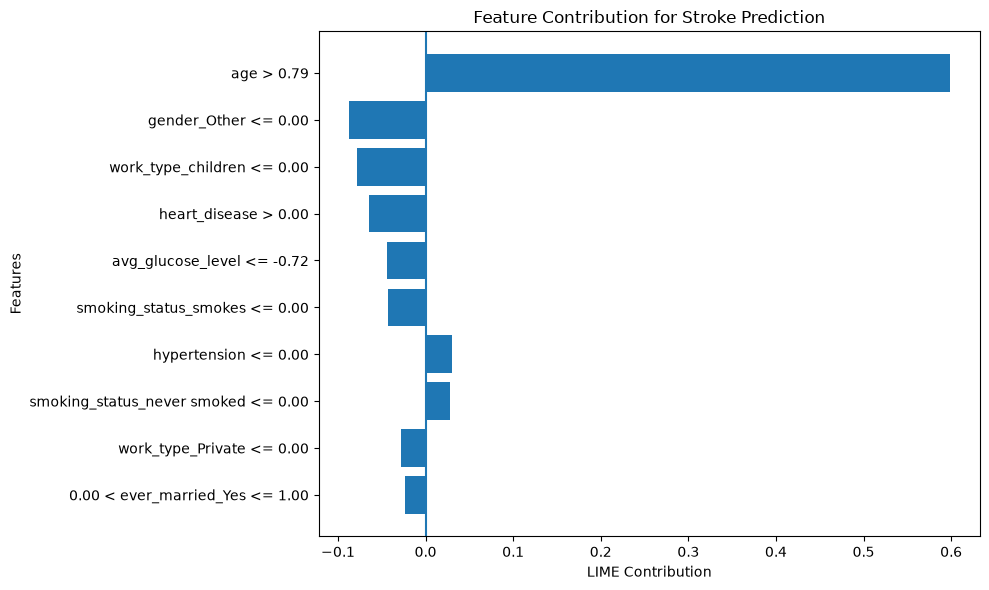

In [27]:
features = []
weights = []

for feature, weight in explanation.as_list():
    features.append(feature)
    weights.append(weight)

plt.figure(figsize=(10, 6))
plt.barh(features, weights)

plt.xlabel("LIME Contribution")
plt.ylabel("Features")
plt.title("Feature Contribution for Stroke Prediction")

plt.axvline(x=0)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()